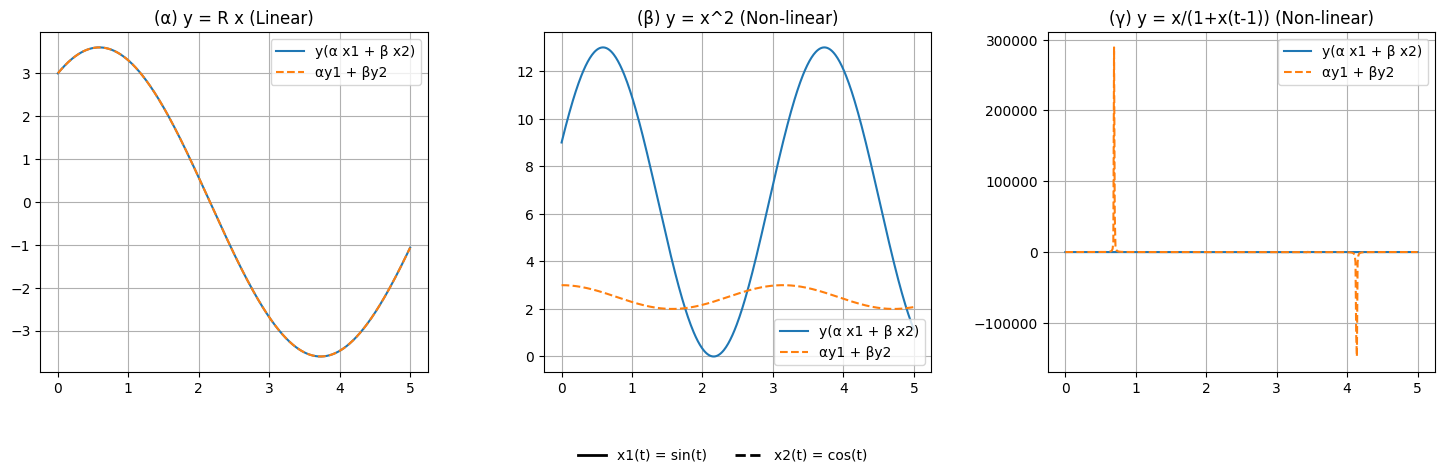

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Time axis
t = np.linspace(0, 5, 500)
dt = t[1]-t[0]

# Inputs
x1 = np.sin(t)  # first input
x2 = np.cos(t)  # second input

alpha = 2
beta = 3

# --------------------
# (α) y = R x (linear)
y1_a = x1
y2_a = x2
y_combo_a = alpha*x1 + beta*x2
y_linear_combo_a = alpha*y1_a + beta*y2_a

# (β) y = x^2 (non-linear)
y1_b = x1**2
y2_b = x2**2
y_combo_b = (alpha*x1 + beta*x2)**2
y_linear_combo_b = alpha*y1_b + beta*y2_b

# (γ) y = x/(1+x(t-1)) (non-linear with delay)
delay_samples = int(1/dt)
x1_shift = np.roll(x1, delay_samples)
x2_shift = np.roll(x2, delay_samples)

y1_c = x1/(1 + x1_shift)
y2_c = x2/(1 + x2_shift)

x_combo = alpha*x1 + beta*x2
x_combo_shift = np.roll(x_combo, delay_samples)
y_combo_c = x_combo/(1 + x_combo_shift)
y_linear_combo_c = alpha*y1_c + beta*y2_c

# --------------------
# Plotting
fig, axs = plt.subplots(1,3, figsize=(18,5))
plt.subplots_adjust(wspace=0.3, bottom=0.2)

# (α) Linear
l1, = axs[0].plot(t, y_combo_a, label='y(α x1 + β x2)')
l2, = axs[0].plot(t, y_linear_combo_a, '--', label='αy1 + βy2')
axs[0].set_title('(α) y = R x (Linear)')
axs[0].grid(True)
axs[0].legend(loc='upper right')

# (β) Non-linear x^2
l3, = axs[1].plot(t, y_combo_b, label='y(α x1 + β x2)')
l4, = axs[1].plot(t, y_linear_combo_b, '--', label='αy1 + βy2')
axs[1].set_title('(β) y = x^2 (Non-linear)')
axs[1].grid(True)
axs[1].legend(loc='lower right')

# (γ) Non-linear with delay
l5, = axs[2].plot(t, y_combo_c, label='y(α x1 + β x2)')
l6, = axs[2].plot(t, y_linear_combo_c, '--', label='αy1 + βy2')
axs[2].set_title('(γ) y = x/(1+x(t-1)) (Non-linear)')
axs[2].grid(True)
axs[2].legend(loc='upper right')

# --------------------
# Common legend for inputs below all plots
fig.legend([plt.Line2D([0],[0], color='k', lw=2), plt.Line2D([0],[0], color='k', lw=2, linestyle='--')],
           ['x1(t) = sin(t)', 'x2(t) = cos(t)'],
           loc='lower center', ncol=2, frameon=False)

plt.show()